In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity

seed = 42
rng = np.random.default_rng(seed)

In [2]:
def select_focus_images(
    image_dataset, threshold_low, threshold_high, num_images=10, seed=42
):
    # draw a random integer between 0 and len(image_dataset)
    rng = np.random.default_rng(seed)
    random_index = rng.integers(0, len(image_dataset))
    focus_images = [image_dataset[random_index]]  # Initialize with the first image

    # sample an image from the dataset without replacement

    for idx, current_image in enumerate(image_dataset[1:]):
        # Reshape the arrays to 2D
        focus_images_matrix = np.vstack(focus_images).reshape(len(focus_images), -1)
        current_image_matrix = current_image.reshape(1, -1)

        cossim_matrix = cosine_similarity(focus_images_matrix, current_image_matrix)

        if np.all((threshold_low < cossim_matrix) & (cossim_matrix < threshold_high)):
            print(f"Adding image with id {idx}")
            focus_images.append(current_image)
            print(f"Number of focus images: {len(focus_images)}")

        if len(focus_images) >= num_images:
            break

    return focus_images

In [3]:
def select_focus_images(
    image_dataset, threshold_low, threshold_high, num_focus_images=10, seed=None
):
    rng = np.random.default_rng(seed)

    # Randomly sample the first focus image
    initial_focus_image = image_dataset[rng.integers(len(image_dataset))]
    focus_images = [initial_focus_image]

    while len(focus_images) < num_focus_images:
        random_index = rng.integers(len(image_dataset))
        current_image = image_dataset[random_index]

        # Reshape the arrays to 2D
        focus_images_matrix = np.vstack(focus_images).reshape(len(focus_images), -1)
        current_image_matrix = current_image.reshape(1, -1)

        cossim_matrix = cosine_similarity(focus_images_matrix, current_image_matrix)

        if np.all((threshold_low < cossim_matrix) & (cossim_matrix < threshold_high)):
            focus_images.append(current_image)

    # Compute the final cosine similarity matrix
    focus_images_matrix = np.vstack(focus_images).reshape(len(focus_images), -1)
    final_cossim_matrix = cosine_similarity(focus_images_matrix)

    return focus_images, final_cossim_matrix

In [4]:
exc_fname = Path("/src/project/data/experiment/exc_images_preprocessed.npy")
exc_images = np.load(exc_fname)
print(exc_images.shape)

(960, 36, 36)


In [5]:
exc_images_mean = exc_images.mean(axis=0)
exc_images = exc_images - exc_images_mean
vmax = np.max(exc_images)
vmin = np.min(exc_images)

In [10]:
# Example usage
# Assuming image_dataset is your list of images
# Adjust the threshold values as needed
threshold_low = -0.2
threshold_high = 0.2

selected_focus_images, _ = select_focus_images(
    exc_images, threshold_low, threshold_high
)

In [11]:
len(selected_focus_images)

10

In [12]:
focus_images_matrix = np.vstack(selected_focus_images).reshape(
    len(selected_focus_images), -1
)
print(focus_images_matrix.shape)

(10, 1296)


In [13]:
cossim = cosine_similarity(focus_images_matrix)

In [14]:
cossim.shape

(10, 10)

In [15]:
cossim_matrix = cosine_similarity(focus_images_matrix, focus_images_matrix)

In [16]:
cossim_matrix.shape

(10, 10)

In [9]:
# compute cosine similarity matrix
focus_images_matrix = np.vstack(selected_focus_images).reshape(
    len(selected_focus_images), -1
)
cossim_matrix = cosine_similarity(focus_images_matrix, focus_images_matrix)

fig, ax = plt.subplots(dpi=300)
# sns.heatmap(cosine_similarity(exc_images[pattern_ids].reshape(G_dim, -1)), annot=True, fmt=".2f", vmin=-1, vmax=1)
sns.heatmap(cossim_matrix, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)

ax.set_title("Cos sim between assigned Gs")

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 2 dimension(s)

In [16]:
selected_focus_images[0].shape

(36, 36)

In [14]:
from probcs.models.pattern_completion_model import PatternCompletionModel

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [19]:
G_prob = 1 / len(selected_focus_images)
x_sigma = 0.1
I_sigma = 20
offset = 0
G_visual_nrows = len(selected_focus_images)
G_visual_ncols = 1
x_visual_nrows = len(selected_focus_images)
x_visual_ncols = 9

In [17]:
model = PatternCompletionModel(
    patterns=selected_focus_images,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    patterns_offset=offset,
)

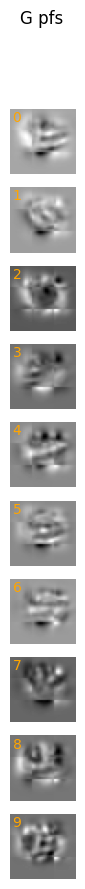

In [20]:
G_productions = model.visualize_learned_G(nrows=G_visual_nrows, ncols=G_visual_ncols)

Text(0.5, 0.98, 'Assigned / PFs')

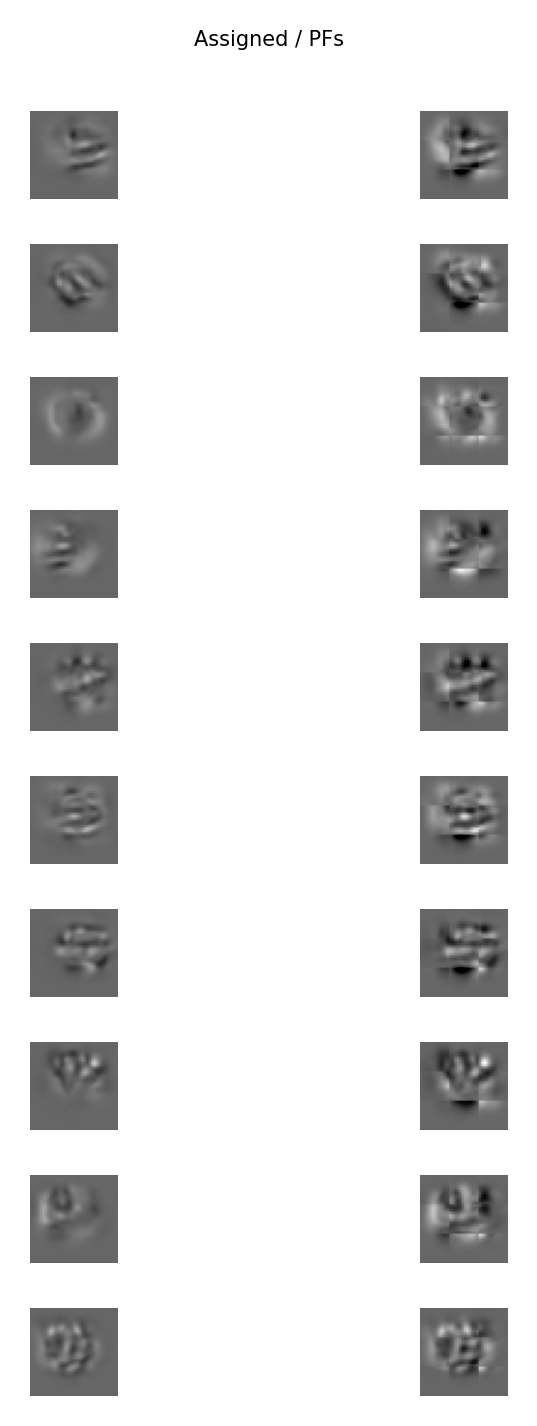

In [21]:
fig, axs = plt.subplots(G_visual_nrows, G_visual_ncols * 2, dpi=300, tight_layout=True)
for idx, ax in enumerate(axs[:, 0].flatten()):
    ax.imshow(model.patterns[idx], cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")
for idx, ax in enumerate(axs[:, 1].flatten()):
    ax.imshow(G_productions[idx], cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

fig.suptitle("Assigned / PFs", fontsize=5)

Text(0.5, 1.0, 'Cos sim between G PFs')

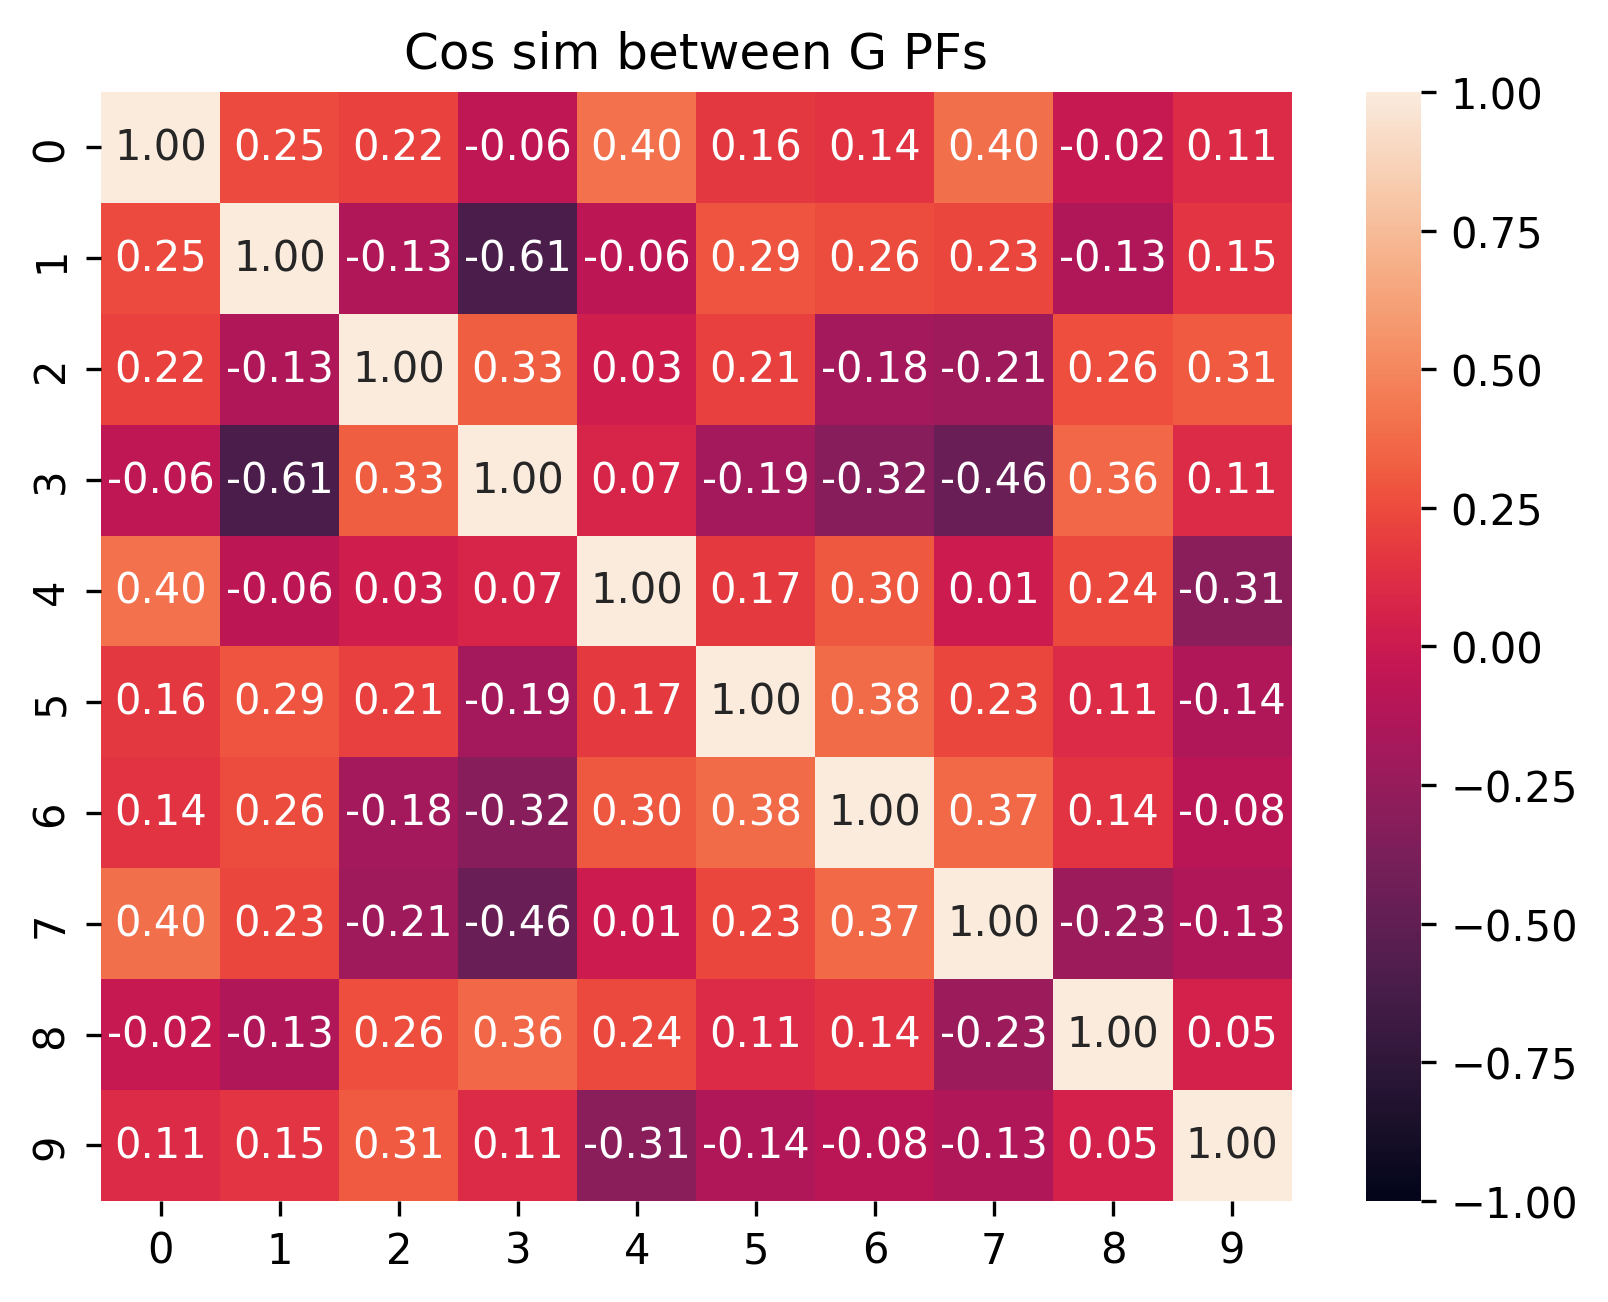

In [23]:
fig, ax = plt.subplots(dpi=300)
sns.heatmap(
    cosine_similarity(G_productions.reshape(model.patterns.shape[0], -1)),
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    ax=ax,
)
ax.set_title("Cos sim between G PFs")